In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random

In [20]:
sns.set(style="whitegrid")
DATASET_PATH = "data"

In [21]:
# detect classes
class_paths = []
class_labels = []

for fruit in os.listdir(DATASET_PATH):
    fruit_path = os.path.join(DATASET_PATH, fruit)
    if os.path.isdir(fruit_path):
        for status in os.listdir(fruit_path):
            status_path = os.path.join(fruit_path, status)
            if os.path.isdir(status_path):
                class_paths.append(status_path)
                class_labels.append(f"{fruit}_{status}")

print("Detected Classes:")
for label in class_labels:
    print(label)

Detected Classes:
Apple_Fresh
Apple_Rotten
Strawberry_Fresh
Strawberry_Rotten
Banana_Fresh
Banana_Rotten


/var/folders/qb/3h2jjrbx1830x27100cy05xh0000gn/T/ipykernel_2545/2142013605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


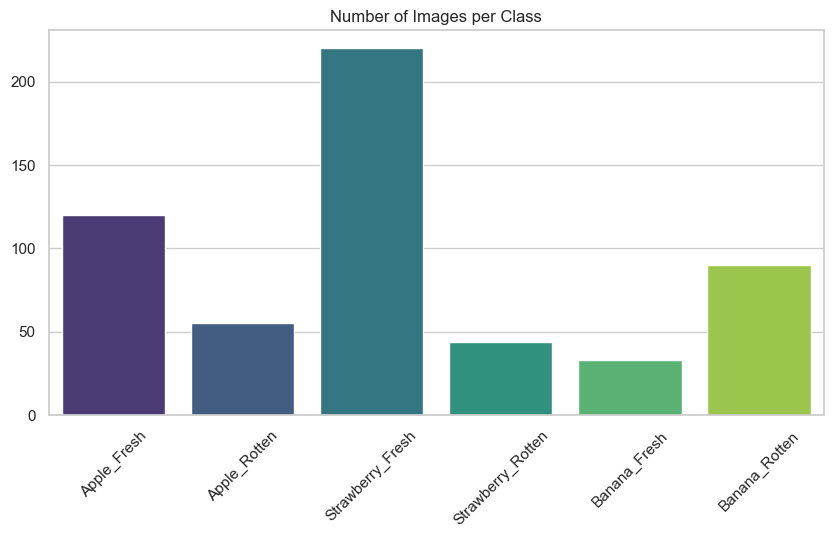

In [22]:
# class distribution
class_counts = {label: len(os.listdir(path)) for label, path in zip(class_labels, class_paths)}

plt.figure(figsize=(10,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Number of Images per Class")
plt.xticks(rotation=45)
plt.show()

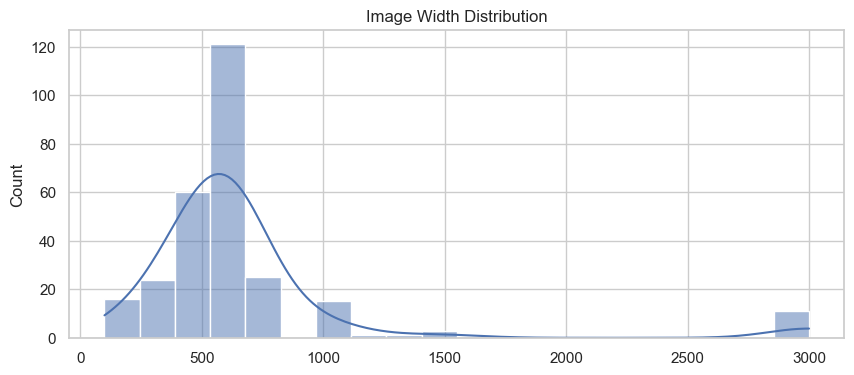

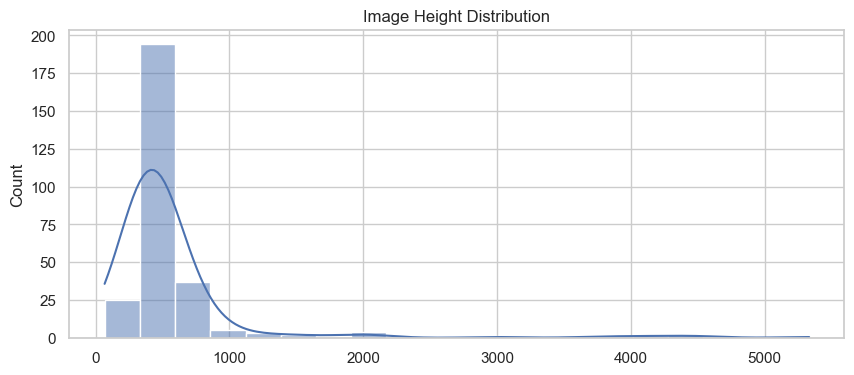

In [23]:
# image size analysis

widths, heights = [], []

for path in class_paths:
    for img_name in os.listdir(path)[:50]:  # sample to speed up
        img = Image.open(os.path.join(path, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10,4))
sns.histplot(widths, bins=20, kde=True)
plt.title("Image Width Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(heights, bins=20, kde=True)
plt.title("Image Height Distribution")
plt.show()

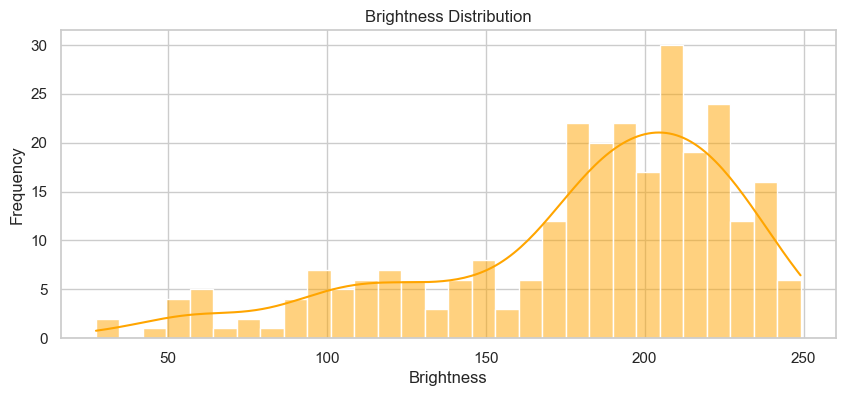

In [24]:
# image brightness analysis
brightness_values = []

for path in class_paths:
    for img_name in os.listdir(path)[:50]:
        img = Image.open(os.path.join(path, img_name))
        gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
        brightness_values.append(np.mean(gray))

plt.figure(figsize=(10,4))
sns.histplot(brightness_values, bins=30, kde=True, color="orange")
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

In [25]:
# build dataset
labels = []
images = []

fruit_types = os.listdir(DATASET_PATH)

for fruit_type in fruit_types:
    fruit_dir = os.path.join(DATASET_PATH, fruit_type)

    if os.path.isdir(fruit_dir):
      freshness_types = os.listdir(fruit_dir)

      for freshness_type in freshness_types:
          freshness_dir = os.path.join(fruit_dir, freshness_type)

          if os.path.isdir(freshness_dir):
             for image_filename in os.listdir(freshness_dir):
                 if image_filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(freshness_dir, image_filename)
                    images.append(image_path)
                    labels.append(freshness_type)


df = pd.DataFrame({'image_path': images, 'label': labels})
df.head()

,image_path,label
0,data/Apple/Fresh/apple_fresh_001.jpg (94).jpg,Fresh
1,data/Apple/Fresh/apple_fresh_001.jpg (82).jpg,Fresh
2,data/Apple/Fresh/apple_fresh_001.jpg (41).jpg,Fresh
3,data/Apple/Fresh/apple_fresh_001.jpg (16).jpg,Fresh
4,data/Apple/Fresh/apple_fresh_001.jpg (57).jpg,Fresh


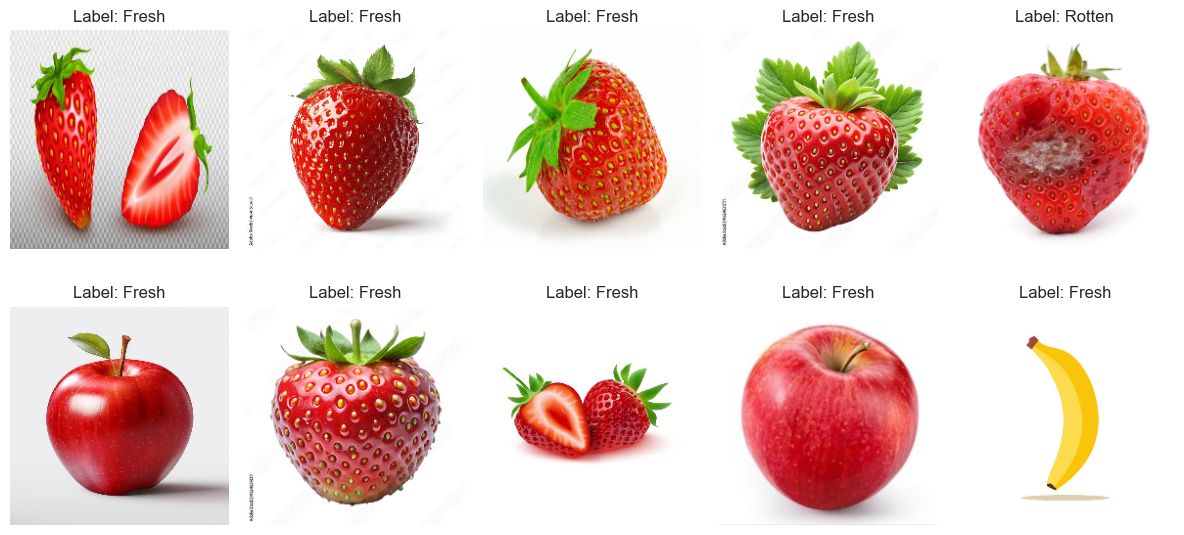

In [26]:
import cv2
labels = df['label'].unique()

plt.figure(figsize=(12, 6))

for i in range(10):
  random_index = random.randint(0, len(df) - 1)
  image_path = df.iloc[random_index]['image_path']
  label = df.iloc[random_index]['label']

  img = plt.imread(image_path).copy()
  resized_img = cv2.resize(img, (224, 224))
  plt.subplot(2, 5, i+1)
  plt.imshow(resized_img)
  plt.title(f"Label: {label}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [27]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['image_path'], df['label'], test_size=0.2, random_state=42)

train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
test_df = pd.DataFrame({'image_path': X_test, 'label': y_test})

train_df.head()

,image_path,label
220,data/Strawberry/Fresh/strawberry_fresh_005.jpg...,Fresh
69,data/Apple/Fresh/apple_fresh_001.jpg (87).jpg,Fresh
362,data/Strawberry/Fresh/strawberry_fresh_005.jpg...,Fresh
483,data/Banana/Rotten/banana_rotten_010.jpg (39).jpg,Rotten
173,data/Strawberry/Fresh/strawberry_fresh_005.jpg...,Fresh


In [28]:
# Data processing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

train_augmentation_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

train_dataset = train_augmentation_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_dataset = test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 420 validated image filenames belonging to 2 classes.
Found 105 validated image filenames belonging to 2 classes.


In [29]:
# Create model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

model = Sequential([
    Input(shape=(224, 224, 3)),
    # First layer
    Conv2D(32, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Second layer
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    # Third layer
    Conv2D(128, kernel_size=3, activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='model')

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# train model
model_history = model.fit(
    train_dataset,
    steps_per_epoch=len(train_dataset),
    validation_data=test_dataset,
    validation_steps=len(test_dataset),
    epochs=30,
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.6049 - loss: 1.8852
Epoch 1: val_loss improved from None to 0.56815, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 430ms/step - accuracy: 0.6143 - loss: 1.2435 - val_accuracy: 0.6571 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.6948 - loss: 0.6064
Epoch 2: val_loss improved from 0.56815 to 0.42383, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 421ms/step - accuracy: 0.7310 - loss: 0.5721 - val_accuracy: 0.7143 - val_loss: 0.4238 - learning_rate: 0.0010
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7921 - loss: 0.4405
Epoch 3: val_loss improved from 0.42383 to 0.28610, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 407ms/step - accuracy:

In [31]:
# Visualizations
def plot_history(history):
  acc = history.history['accuracy']
  loss = history.history['loss']

  val_acc = history.history['val_accuracy']
  val_loss = history.history['val_loss']

  epochs = range(len(acc))

  plt.figure(figsize=(12, 6))

  plt.subplot(2, 2, 1)
  plt.plot(epochs, acc, 'r', label='Training Accuracy')
  plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()

  plt.subplot(2, 2, 2)
  plt.plot(epochs, loss, 'r', label='Training Loss')
  plt.plot(epochs, val_loss, 'b', label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.legend()

  plt.tight_layout()
  plt.show()


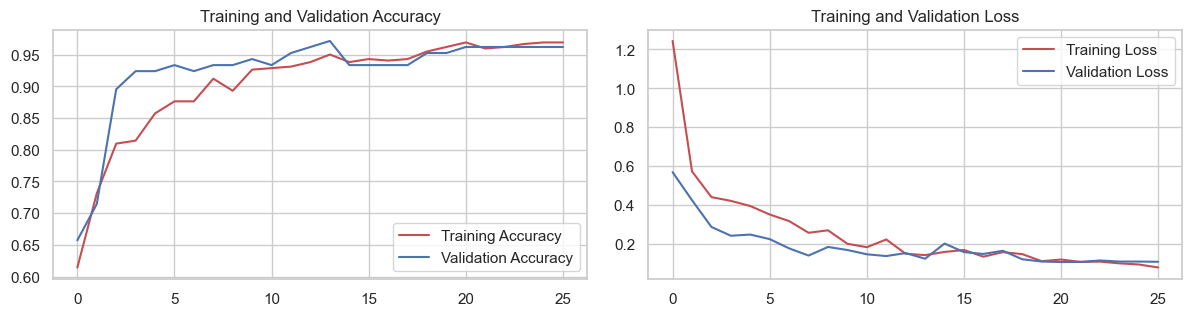

In [32]:
plot_history(model_history)

In [33]:
# Evuate results
model.evaluate(test_dataset)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9619 - loss: 0.1056


[0.1055774986743927, 0.961904764175415]

In [34]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

preds = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


In [35]:
# Compare result with expected result
class_indices = train_dataset.class_indices

idx_to_class = {v: k for k, v in class_indices.items()}

# Corrected prediction for binary classification
predicted_class_indices = (preds > 0.5).astype(int).flatten() # Threshold at 0.5 and flatten

predicted_classes = [idx_to_class[idx] for idx in predicted_class_indices]

print("First 10 predicted class labels")
for i, label in enumerate(predicted_classes[:10]):
  print(f"Image {i+1}: {label}")

test_df['predicted_label'] = predicted_classes

display(test_df.head(10))

First 10 predicted class labels
Image 1: Fresh
Image 2: Rotten
Image 3: Fresh
Image 4: Fresh
Image 5: Fresh
Image 6: Fresh
Image 7: Rotten
Image 8: Rotten
Image 9: Rotten
Image 10: Rotten


,image_path,label,predicted_label
310,data/Strawberry/Fresh/strawberry_fresh_005.jpg...,Fresh,Fresh
390,data/Strawberry/Rotten/strawberry_rotten_005.j...,Rotten,Rotten
6,data/Apple/Fresh/apple_fresh_001.jpg (98).jpg,Fresh,Fresh
184,data/Strawberry/Fresh/strawberry_fresh_005.jpg...,Fresh,Fresh
78,data/Apple/Fresh/apple_fresh_001.jpg (64).jpg,Fresh,Fresh
407,data/Strawberry/Rotten/strawberry_rotten_005.j...,Rotten,Fresh
524,data/Banana/Rotten/banana_rotten_010.jpg (28).jpg,Rotten,Rotten
487,data/Banana/Rotten/banana_rotten_010.jpg (54).jpg,Rotten,Rotten
117,data/Apple/Rotten/apple_rotten_001.jpg (54).jpg,Rotten,Rotten
137,data/Apple/Rotten/apple_rotten_001.jpg (45).jpg,Rotten,Rotten
